## 1. Imports

In [70]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.lines import Line2D

sys.path.insert(0, str(Path("../../nogse_pipeline/src")))
from models.model_fitting import M_ogse_free, M_ogse_rest, M_ogse_mixed, M_ogse_tort


## 2. Config

Edit `LAB_FOLDER` to point to a subfolder of `lab/` that contains a `fit_results.xlsx`
produced by one of the `fit_ogse_*.ipynb` notebooks (which must have been run with a
`MODEL_NAME` parameter in their config cell).


In [71]:
LAB_ROOT   = Path("../../analysis/brains/ogse_experiments/lab")
LAB_FOLDER = "fit_mixed-mixed-norm-interpolate"   # ← choose any subfolder of lab/

# ── Contrast definition ────────────────────────────────────────────────────────
N_HIGH = 8   # contrast = signal(N_HIGH) – signal(N_LOW)
N_LOW  = 4

# ── Physics constant ───────────────────────────────────────────────────────────
GYRO = 267.52218744  # ms⁻¹ mT⁻¹  (1H gyromagnetic ratio)

# ── Master data ────────────────────────────────────────────────────────────────
MASTER_PATH = Path("../../analysis/brains/ogse_experiments/master.long.parquet")

# ── Rician noise override ─────────────────────────────────────────────────────
RN_ZERO = False  # True → evaluate all models with RN=0 (ignore fit value)


## 3. Load data

In [72]:
_subdir = "contrast_RN=0" if RN_ZERO else "contrast"
OUT_DIR = LAB_ROOT / LAB_FOLDER / _subdir
OUT_DIR.mkdir(parents=True, exist_ok=True)

results_df = pd.read_excel(LAB_ROOT / LAB_FOLDER / "fit_results.xlsx")

# ── Read model name saved by the fit notebook ──────────────────────────────────
if "model_name" not in results_df.columns:
    raise KeyError(
        "Column 'model_name' not found in fit_results.xlsx.\n"
        "Re-run the fit notebook after adding MODEL_NAME to its config cell."
    )
MODEL_NAME = str(results_df["model_name"].iloc[0])
print(f"Model name: {MODEL_NAME!r}")

# ── Recover fitting metadata ───────────────────────────────────────────────────
g_col = str(results_df["g_column"].iloc[0])
_gcr  = results_df["g_correction_column"].iloc[0] if "g_correction_column" in results_df.columns else None
g_corr_col = None if (_gcr is None or pd.isna(_gcr) or str(_gcr) in ("None", "nan")) else str(_gcr)
y_col = str(results_df["y_column"].iloc[0])
D0    = float(results_df["D0_m2ms"].iloc[0])

# ── Load master data ───────────────────────────────────────────────────────────
df_master = pd.read_parquet(MASTER_PATH)
data = df_master[(df_master.row_kind == "signal_rotated") & (df_master.stat == "avg")].copy()
data["G_corr"] = data[g_col].astype(float)
if g_corr_col and g_corr_col in data.columns:
    data["G_corr"] *= data[g_corr_col].astype(float)
data["y_val"] = data[y_col].astype(float)
data["y_raw"] = data["value"].astype(float)  # raw a.u. signal for RN normalisation

G_dense    = np.linspace(0, float(data.G_corr.max()), 400)
DIRECTIONS = sorted(results_df.direction.unique())
N_LIST     = sorted(results_df.N.unique())
ROI_LIST   = sorted(results_df.roi.unique())
SUBJ_LIST  = sorted(results_df.subj.unique())
TD_LIST    = sorted(float(t) for t in results_df.td_ms.unique())

assert N_HIGH in N_LIST, f"N_HIGH={N_HIGH} not in fit results (found {N_LIST})"
assert N_LOW  in N_LIST, f"N_LOW={N_LOW}  not in fit results (found {N_LIST})"

print(f"D0         : {D0} m²/ms  |  y column: {y_col}")
print(f"Subjects   : {SUBJ_LIST}")
print(f"Directions : {DIRECTIONS}")
print(f"ROIs       : {ROI_LIST}")
print(f"td [ms]    : {TD_LIST}")
print(f"Contrast   : N{N_HIGH} – N{N_LOW}")
print(f"Output dir : {OUT_DIR}")


Model name: 'mixed-mixed'
D0         : 3e-12 m²/ms  |  y column: value_norm
Subjects   : ['BRAIN', 'LUDG', 'MBBL']
Directions : ['long', 'tra']
ROIs       : ['AntCC', 'CentralCC', 'Left-Lateral-Ventricle', 'MidAntCC', 'MidPostCC', 'PostCC', 'Right-Lateral-Ventricle']
td [ms]    : [76.0, 90.0, 120.0, 143.4, 210.0]
Contrast   : N8 – N4
Output dir : ../../analysis/brains/ogse_experiments/lab/fit_mixed-mixed-norm-interpolate/contrast


## 4. Signal reconstruction helpers

In [73]:
# ── Row and S0 lookup ──────────────────────────────────────────────────────────
def _get_row(subj, roi, direction, td, N):
    mask = (
        (results_df.subj == subj) & (results_df.roi == roi) &
        (results_df.direction == direction) & (results_df.N == N) &
        np.isclose(results_df.td_ms.astype(float), float(td))
    )
    rows = results_df[mask]
    return rows.iloc[0] if not rows.empty else None


def _get_S0(subj, roi, direction, td, N):
    """Raw signal at G≈0 in a.u.; used to normalise RN for fraction-parametrised models.
    Always reads the raw 'value' column, not the fitted y_col, matching the fit notebook.
    """
    sub = data[
        (data.subj == subj) & (data.roi == roi) & (data.direction == direction) &
        (data.N == N) & np.isclose(data.td_ms.astype(float), float(td))
    ].sort_values("G_corr")
    return float(sub.iloc[0]["y_raw"]) if not sub.empty else 1.0


def _col(row, name, default=0.0):
    """Safely read a column value that may not exist in older fit results."""
    v = getattr(row, name, None)
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return default
    return float(v)


# ── Per-model signal functions ─────────────────────────────────────────────────
def _signal(G, td, N, row, model_name, S0=1.0):
    """
    Dispatch to the correct signal formula based on model_name.

    model_name  formula
    ----------  ──────────────────────────────────────────────────────────────
    free        M_ogse_free(M0, D0)
    rest        M_ogse_rest(tc, M0, D0)
    mixed       M_ogse_mixed(tc, alpha, M0, D0) + Rician(RN)
    mixed-rest  M_ogse_mixed(tc, alpha, M0) + M_ogse_rest(tc2, M02) + Rician(RN)
    mixed-tort  two sub-cases detected from M02:
                  M02 > 0: M_mixed(tc, alpha, M0) + M_tort(alpha2, M02)  + Rician(RN)
                  M02 = 0: M0·M_mixed(tc, alpha, 1) + (1−M0)·M_tort(alpha2, 1) + Rician(RN/S0)
    rest-tort   M_ogse_rest(tc, M0) + M_ogse_tort(alpha2, M02) + Rician(RN)
    mixed-mixed two sub-cases detected from M02:
                  M02 > 0: M_mixed(tc, alpha, M0) + M_mixed(tc2, alpha2, M02) + Rician(RN)
                  M02 = 0: M0·M_mixed(tc, alpha, 1) + (1−M0)·M_mixed(tc2, alpha2, 1) + Rician(RN/S0)
    """
    x  = td / N
    tc     = _col(row, "tc_ms",  0.0)
    tc2    = _col(row, "tc2_ms", 0.0)
    alpha  = _col(row, "alpha",  0.0)
    alpha2 = _col(row, "alpha2", alpha)  # fall back to alpha when not saved
    M0     = _col(row, "M0",     1.0)
    M02    = _col(row, "M02",    0.0)
    C      = _col(row, "C",      0.0)
    RN     = 0.0 if RN_ZERO else _col(row, "RN",     0.0)

    with np.errstate(over="ignore", invalid="ignore"):
        if model_name == "free":
            s = M_ogse_free(td, G, N, x, M0, D0)
            return np.where(np.isfinite(s), s, np.nan)

        elif model_name == "rest":
            s = M_ogse_rest(td, G, N, x, tc, M0, D0) + C
            return np.sqrt(np.maximum(s**2 + RN**2, 0.0))

        elif model_name == "mixed":
            s = M_ogse_mixed(td, G, N, x, tc, alpha, M0, D0) + C
            return np.sqrt(np.maximum(s**2 + RN**2, 0.0))

        elif model_name == "mixed-rest":
            s = (M_ogse_mixed(td, G, N, x, tc,  alpha, M0,  D0)
               + M_ogse_rest( td, G, N, x, tc2, M02, D0) + C)
            return np.sqrt(np.maximum(s**2 + RN**2, 0.0))

        elif model_name == "mixed-tort":
            if abs(M02) > 1e-9:
                # amplitude form: independent M0 and M02
                s = (M_ogse_mixed(td, G, N, x, tc, alpha, M0,  D0)
                   + M_ogse_tort( td, G, N, x, alpha2,    M02, D0) + C)
                return np.sqrt(np.maximum(s**2 + RN**2, 0.0))
            else:
                # fraction form: M0 + (1−M0), Rician normalised by S0
                s = (M0 * M_ogse_mixed(td, G, N, x, tc, alpha, 1.0, D0)
                   + (1.0 - M0) * M_ogse_tort(td, G, N, x, alpha2, 1.0, D0) + C)
                RN_norm = RN / S0 if S0 > 0 else 0.0
                return np.sqrt(np.maximum(s**2 + RN_norm**2, 0.0))

        elif model_name == "rest-tort":
            s = (M_ogse_rest(td, G, N, x, tc,    M0,  D0)
               + M_ogse_tort(td, G, N, x, alpha2, M02, D0) + C)
            return np.sqrt(np.maximum(s**2 + RN**2, 0.0))

        elif model_name == "mixed-mixed":
            if abs(M02) > 1e-9:
                # amplitude form: independent M0 and M02
                s = (M_ogse_mixed(td, G, N, x, tc,  alpha,  M0,  D0)
                   + M_ogse_mixed(td, G, N, x, tc2, alpha2, M02, D0) + C)
                return np.sqrt(np.maximum(s**2 + RN**2, 0.0))
            else:
                # fraction form: M0 + (1−M0), Rician normalised by S0
                s = (M0 * M_ogse_mixed(td, G, N, x, tc,  alpha,  1.0, D0)
                   + (1.0 - M0) * M_ogse_mixed(td, G, N, x, tc2, alpha2, 1.0, D0) + C)
                RN_norm = RN / S0 if S0 > 0 else 0.0
                return np.sqrt(np.maximum(s**2 + RN_norm**2, 0.0))

        else:
            raise ValueError(f"Unknown model_name {model_name!r}. "
                             "Expected one of: free, rest, mixed, mixed-rest, "
                             "mixed-tort, rest-tort, mixed-mixed.")


# ── Public interface ───────────────────────────────────────────────────────────
def fit_curve(G, td, N, subj, roi, direction):
    """Reconstructed signal vs corrected gradient G for one (subj, roi, dir, td, N)."""
    row = _get_row(subj, roi, direction, td, N)
    if row is None:
        return np.full(len(G), np.nan)
    S0 = _get_S0(subj, roi, direction, td, N)
    y  = _signal(G, td, N, row, MODEL_NAME, S0=S0)
    return np.where(np.isfinite(y), y, np.nan)


def contrast_curve(G, td, subj, roi, direction):
    """Contrast = fit(N_HIGH) – fit(N_LOW) at gradient values G."""
    return (fit_curve(G, td, N_HIGH, subj, roi, direction)
          - fit_curve(G, td, N_LOW,  subj, roi, direction))



def _get_peak_tc(td, subj, roi, direction):
    """
    Peak of the contrast curve as plotted in sections 5 and 6:
      - evaluates contrast on the same G grid used for all plots
      - finds the G where |contrast| is maximum
      - converts that G to lcf [µm] and then to tc [ms] via tc = (lcf × 10⁻⁶)² / D0
    Returns (tc_peak_ms, lcf_peak_um).
    """
    # Same call as the plots — G_plot_grid is the shared evaluation grid
    G_plot_grid = G_dense          # G_dense = np.linspace(0, G_max, 400), same as all figures
    ctr = contrast_curve(G_plot_grid, td, subj, roi, direction)

    # Ignore G=0: lcf → ∞ there and is never plotted
    mask = np.isfinite(ctr) & (G_plot_grid > 0)
    if not np.any(mask):
        return np.nan, np.nan

    idx    = np.argmax(np.abs(ctr[mask]))      # index of max |contrast| in the plotted curve
    G_pk   = G_plot_grid[mask][idx]
    lcf_pk = G_to_xvar(np.array([G_pk]), td, "lcf")[0]   # x-coordinate in the lcf plot
    if not np.isfinite(lcf_pk) or lcf_pk <= 0:
        return np.nan, np.nan

    tc_pk = (lcf_pk * 1e-6) ** 2 / D0         # tc [ms] from lcf² = D0 · tc
    return tc_pk, float(lcf_pk)

# ── Gradient → derived axes ────────────────────────────────────────────────────
def G_to_xvar(G_mTm, td_ms, xvar):
    """
    Transform corrected gradient G [mT/m] to a derived axis:
      'Ld'   – dimensionless diffusion-length ratio  l_d / l_G
      'Lcf'  – dimensionless char.-frequency length  (3/2)^(1/4) Ld^(-1/2)
      'lcf'  – physical char. length  lcf [µm]  =  Lcf × l_G × 10^6
    where  l_d = sqrt(D0·td)  and  l_G = (D0 / (γ·G))^(1/3).
    """
    g     = np.asarray(G_mTm, dtype=float)
    valid = (g > 0) & np.isfinite(g)
    out   = np.full_like(g, np.nan)
    if not np.any(valid):
        return out
    l_d   = np.sqrt(D0 * td_ms)
    l_G   = (D0 / (GYRO * g[valid])) ** (1.0 / 3.0)
    Ld_v  = l_d / l_G
    Lcf_v = 1.5 ** 0.25 * Ld_v ** (-0.5)
    lcf_v = Lcf_v * l_G * 1e6   # [µm]
    if   xvar == "Ld":  out[valid] = Ld_v
    elif xvar == "Lcf": out[valid] = Lcf_v
    elif xvar == "lcf": out[valid] = lcf_v
    else: raise ValueError(f"Unknown xvar {xvar!r}. Expected 'Ld', 'Lcf', or 'lcf'.")
    return out


X_LABELS = {
    "g":   "G [mT/m]",
    "Ld":  r"$L_d$ (dimensionless)",
    "Lcf": r"$L_{cf}$ (dimensionless)",
    "lcf": r"$l_{cf}$ [µm]",
}


## 5. Fit-norm plots with contrast

One figure per `(subj, roi, direction)`. Columns = td values.  
Each panel:
- **left axis (log)**: N_LOW scatter + fit, N_HIGH scatter + fit
- **right axis (linear, dashed green)**: contrast N_HIGH − N_LOW

Saved as `fit_norm_contrast_<subj>_<roi>_<direction>.png`.


In [74]:
N_COLORS     = {N_LOW: "C0", N_HIGH: "C1"}
CONTRAST_CLR = "C2"

for subj in SUBJ_LIST:
    for roi in ROI_LIST:
        for direction in DIRECTIONS:
            tds = sorted(float(t) for t in results_df[
                (results_df.subj == subj) & (results_df.roi == roi) &
                (results_df.direction == direction)
            ].td_ms.unique())
            if not tds:
                continue

            fig, axes = plt.subplots(1, len(tds), figsize=(4.5 * len(tds), 4.2), sharey=False)
            axes = np.atleast_1d(axes)

            for ax, td in zip(axes, tds):
                ax_c = ax.twinx()

                for N in [N_LOW, N_HIGH]:
                    color = N_COLORS[N]
                    sub = data[
                        (data.subj == subj) & (data.roi == roi) &
                        (data.direction == direction) & (data.N == N) &
                        np.isclose(data.td_ms.astype(float), td)
                    ].sort_values("G_corr")
                    if not sub.empty:
                        ax.scatter(sub.G_corr, sub.y_val, color=color, s=15, alpha=0.7, zorder=4)
                    ax.plot(G_dense, fit_curve(G_dense, td, N, subj, roi, direction),
                            color=color, lw=1.5)

                ctr = contrast_curve(G_dense, td, subj, roi, direction)
                ax_c.plot(G_dense, ctr, color=CONTRAST_CLR, lw=2, ls="--")
                ax_c.axhline(0, color=CONTRAST_CLR, lw=0.5, ls=":")
                ax_c.set_ylabel("Contrast", color=CONTRAST_CLR, fontsize=7)
                ax_c.tick_params(axis="y", labelcolor=CONTRAST_CLR, labelsize=6)

                ax.set_title(f"td = {td:.0f} ms", fontsize=8)
                ax.set_xlabel("G [mT/m]", fontsize=8)
                ax.set_yscale("log")
                ax.grid(True, which="major", ls="--", lw=0.5, alpha=0.5)
                ax.set_axisbelow(True)
                ax.tick_params(labelsize=7)

            axes[0].set_ylabel(y_col, fontsize=8)
            fig.legend(
                handles=[
                    Line2D([0],[0], color=N_COLORS[N_LOW],  lw=1.5, label=f"N={N_LOW} fit"),
                    Line2D([0],[0], color=N_COLORS[N_HIGH], lw=1.5, label=f"N={N_HIGH} fit"),
                    Line2D([0],[0], ls="", marker="o", color=N_COLORS[N_LOW],  ms=5,
                           label=f"N={N_LOW} data"),
                    Line2D([0],[0], ls="", marker="o", color=N_COLORS[N_HIGH], ms=5,
                           label=f"N={N_HIGH} data"),
                    Line2D([0],[0], color=CONTRAST_CLR, lw=2, ls="--",
                           label=f"N{N_HIGH}−N{N_LOW} contrast"),
                ],
                fontsize=6, loc="upper right", ncol=3,
            )
            fig.suptitle(f"{subj}  |  {roi}  |  {direction}  [{MODEL_NAME}]", fontsize=9)
            fig.tight_layout()
            fig.savefig(OUT_DIR / f"fit_norm_contrast_{subj}_{roi}_{direction}.png", dpi=120)
            plt.close(fig)

print("fit_norm + contrast plots saved.")


fit_norm + contrast plots saved.


## 6. Summary contrast figures

`_summary_contrast_figure(subj, xvar)` builds one figure per subject:  
- **rows** = ROIs, **columns** = directions, **curves** = td values (plasma colourmap)

`xvar`: `"g"`, `"Ld"`, `"Lcf"`, `"lcf"`.


In [75]:
def _summary_contrast_figure(subj, xvar="g"):
    td_arr = np.array(sorted(TD_LIST))
    t_norm = (td_arr - td_arr.min()) / max(float(td_arr.max() - td_arr.min()), 1.0)
    cmap_td = cm.plasma

    fig, axes = plt.subplots(
        len(ROI_LIST), len(DIRECTIONS),
        figsize=(4.5 * len(DIRECTIONS), 3.2 * len(ROI_LIST)),
        squeeze=False,
        constrained_layout=True,
    )

    for i_roi, roi in enumerate(ROI_LIST):
        for i_dir, direction in enumerate(DIRECTIONS):
            ax = axes[i_roi, i_dir]
            for td, tn in zip(td_arr, t_norm):
                color = cmap_td(float(tn))
                ctr   = contrast_curve(G_dense, td, subj, roi, direction)
                x     = G_dense.copy() if xvar == "g" else G_to_xvar(G_dense, td, xvar)
                ok    = np.isfinite(x) & np.isfinite(ctr)
                if not np.any(ok):
                    continue
                idx = np.argsort(x[ok])
                ax.plot(x[ok][idx], ctr[ok][idx], color=color, lw=1.5, label=f"{td:.0f}")
            ax.axhline(0, color="gray", lw=0.5, ls=":")
            ax.set_xlabel(X_LABELS.get(xvar, xvar), fontsize=8)
            ax.grid(True, which="major", ls="--", lw=0.5, alpha=0.5)
            ax.set_axisbelow(True)
            ax.tick_params(labelsize=7)
            if i_dir == 0:
                ax.set_ylabel(f"{roi}\nN{N_HIGH}−N{N_LOW}", fontsize=8)
            if i_roi == 0:
                ax.set_title(direction, fontsize=9)

    h, l = axes[0, -1].get_legend_handles_labels()
    if h:
        axes[0, -1].legend(handles=h, labels=[f"{float(ll):.0f} ms" for ll in l],
                           title="td", fontsize=6, title_fontsize=7, loc="best")

    fig.suptitle(
        f"{subj}  [{MODEL_NAME}]  |  contrast N{N_HIGH}−N{N_LOW}"
        f"  vs  {X_LABELS.get(xvar, xvar)}",
        fontsize=10,
    )
    return fig


### 6a. Contrast vs G

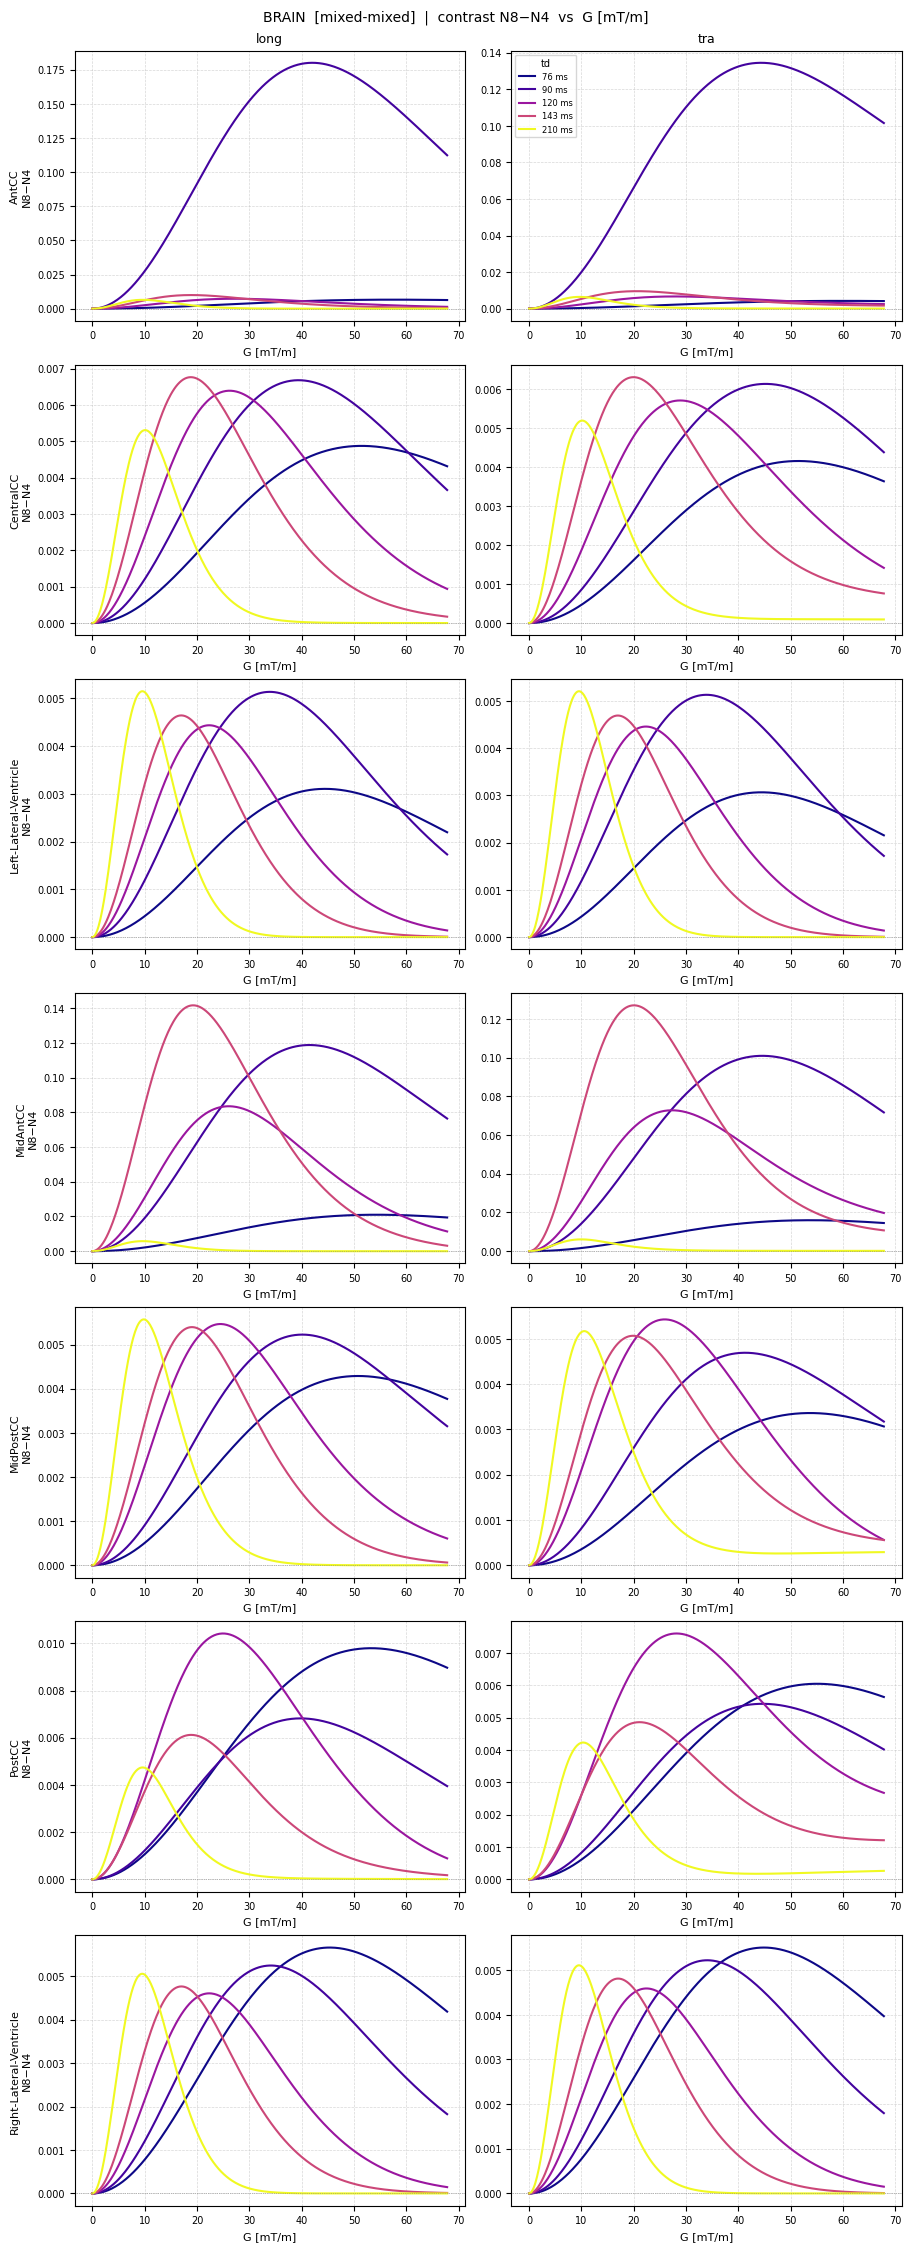

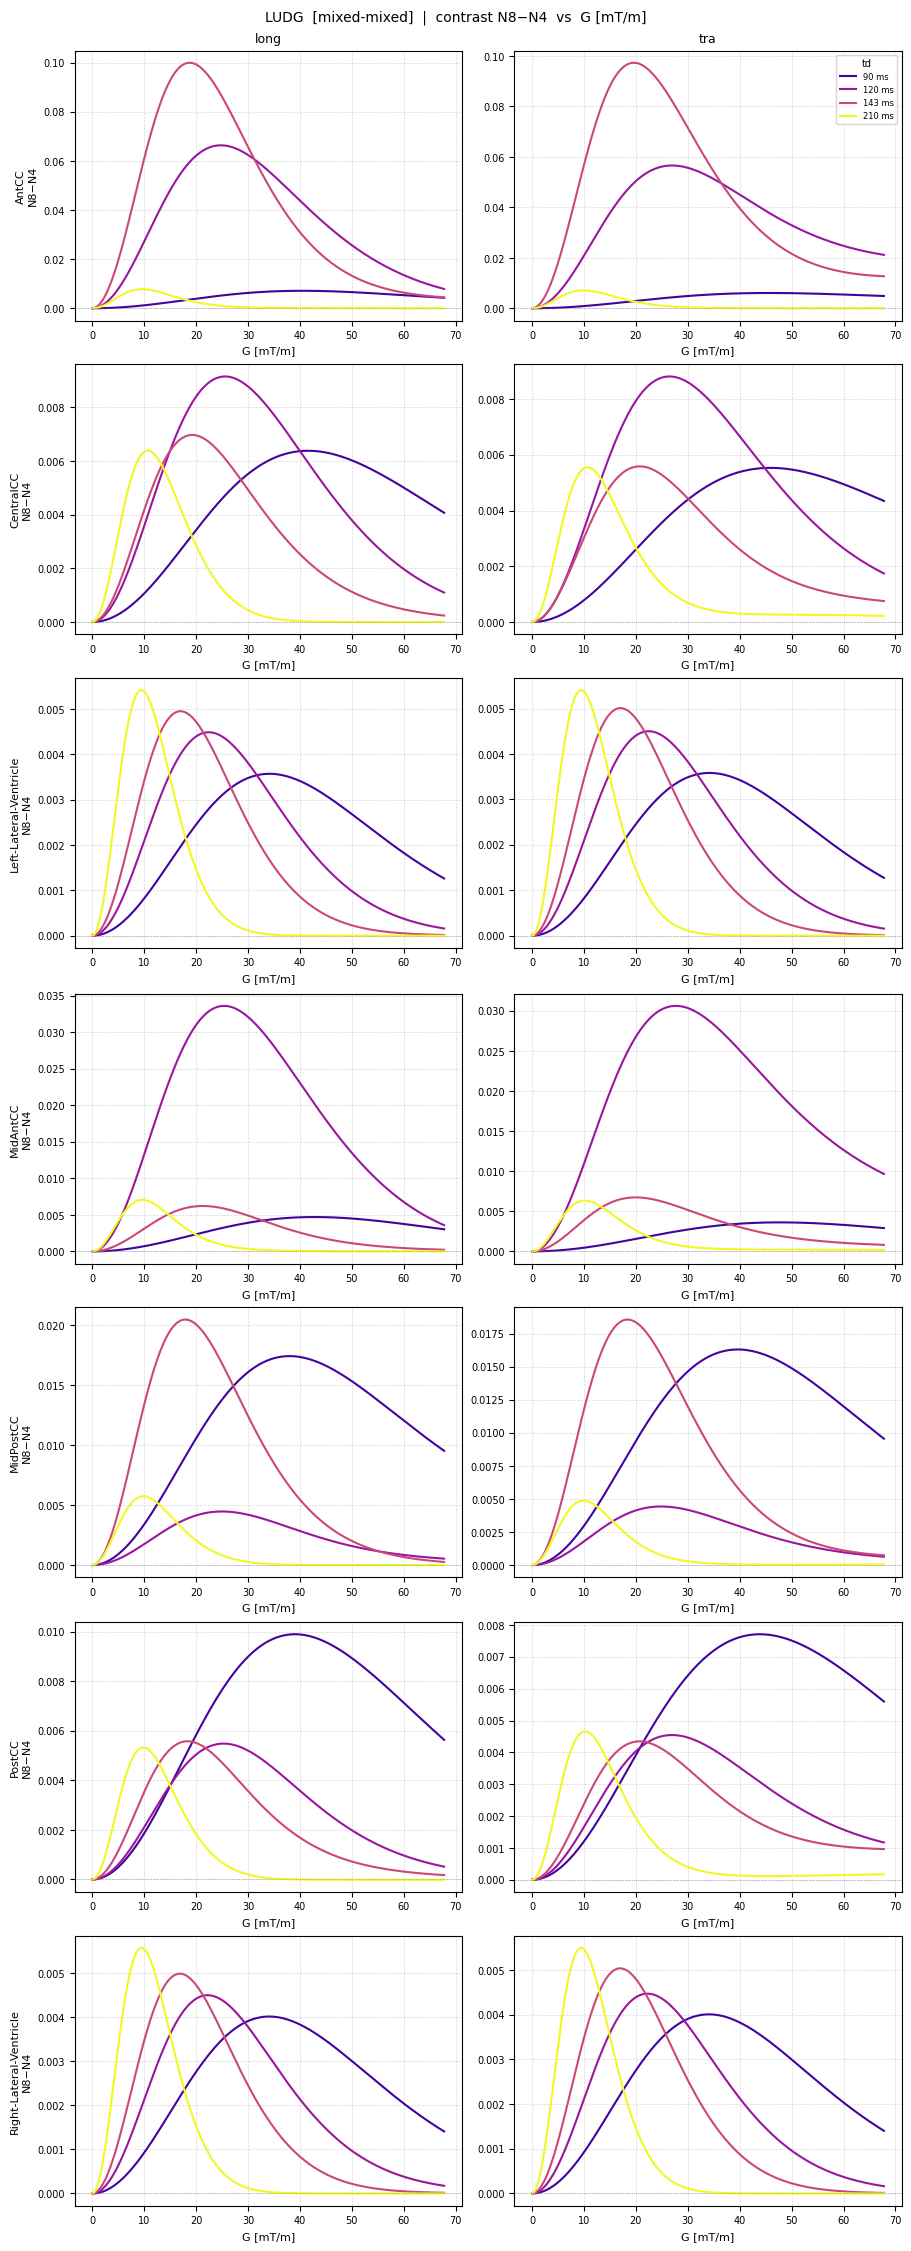

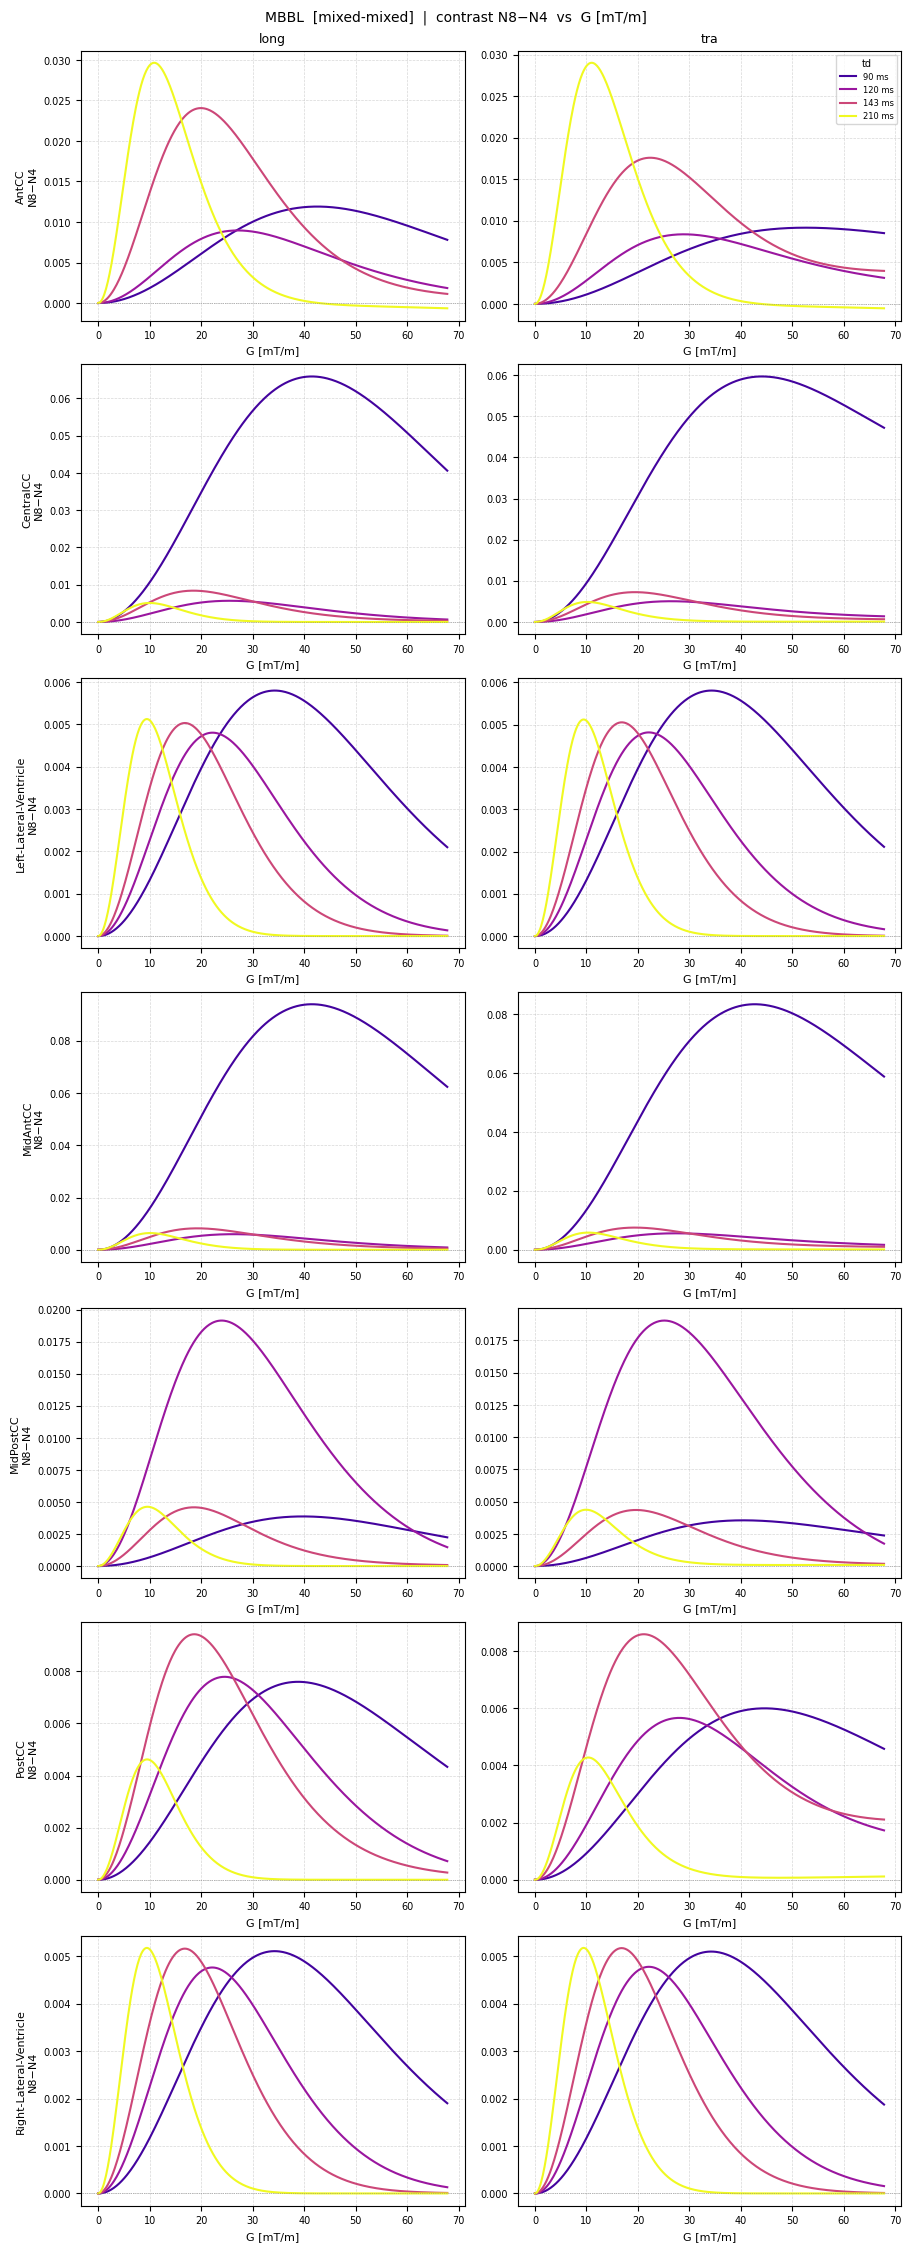

In [76]:
for subj in SUBJ_LIST:
    fig = _summary_contrast_figure(subj, xvar='g')
    fig.savefig(OUT_DIR / f"contrast_vs_g_{subj}.png", dpi=120)
    plt.show()


### 6b. Contrast vs $L_d$

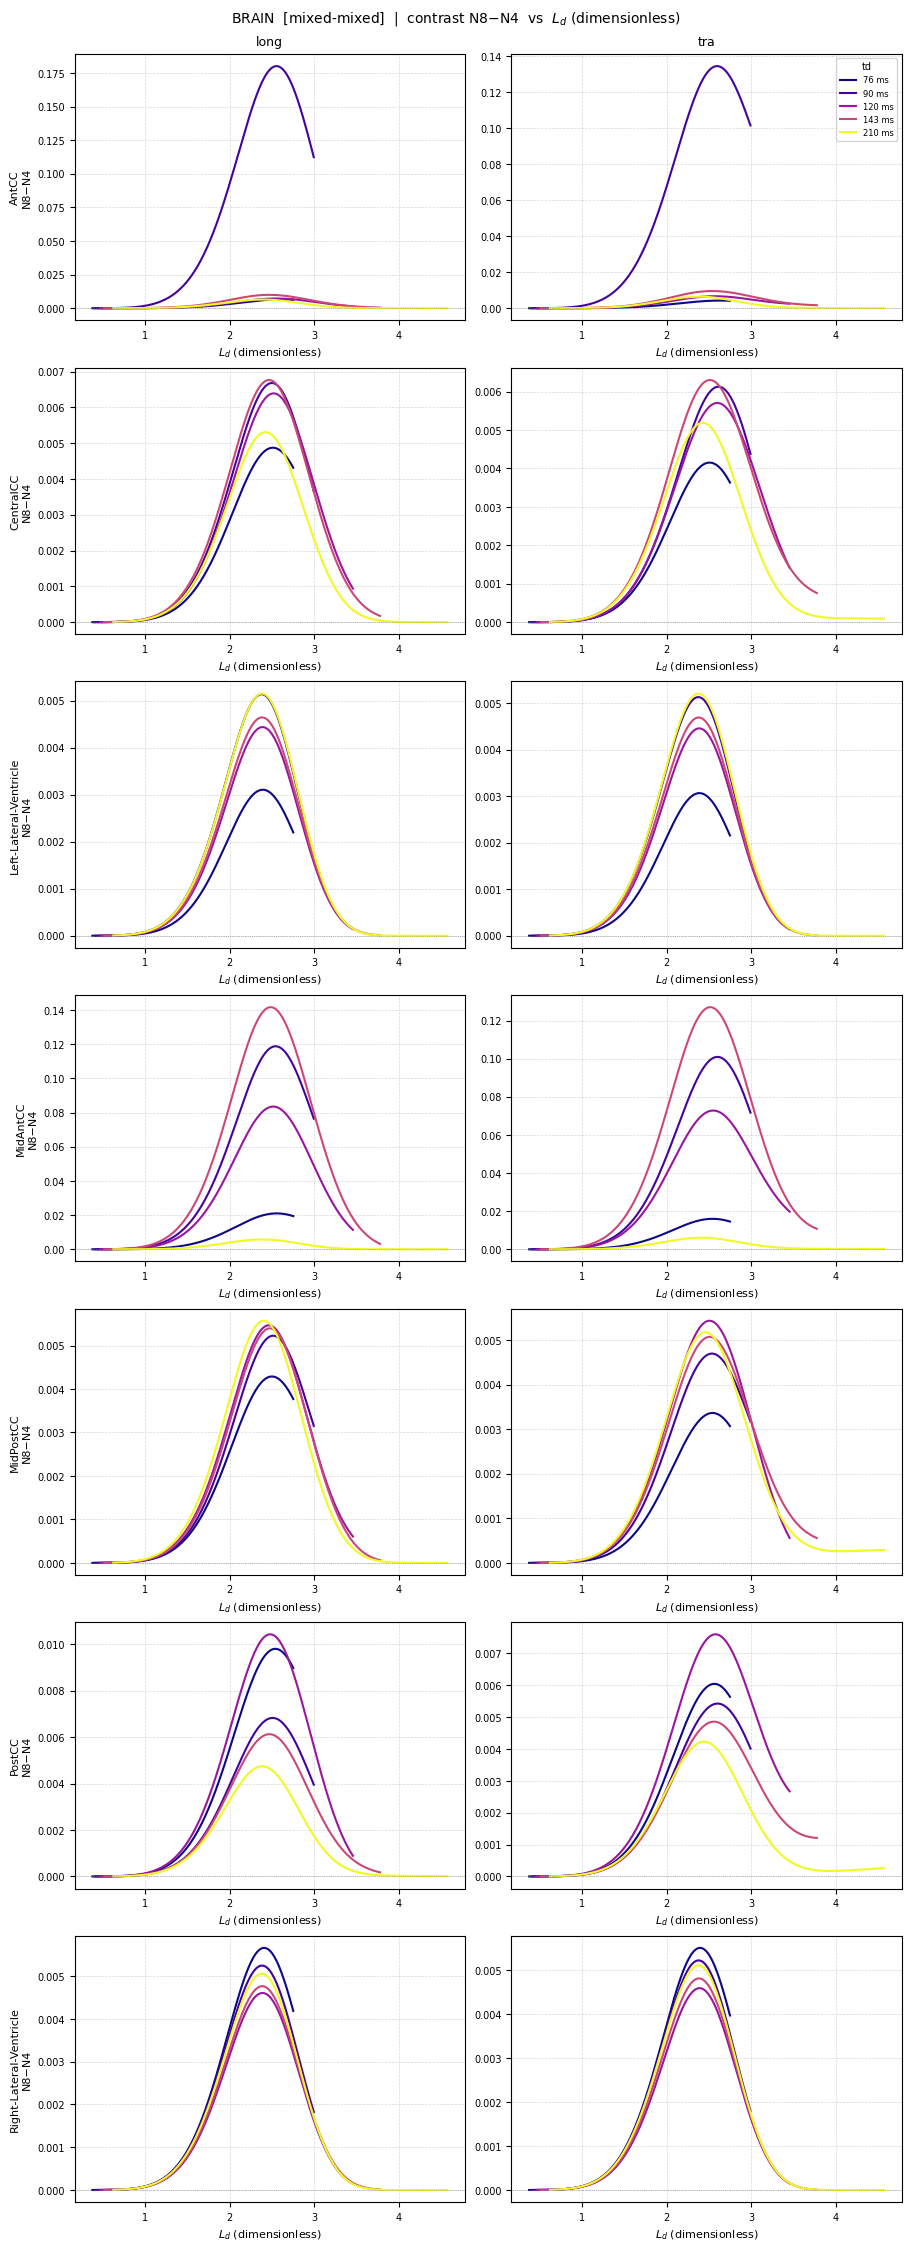

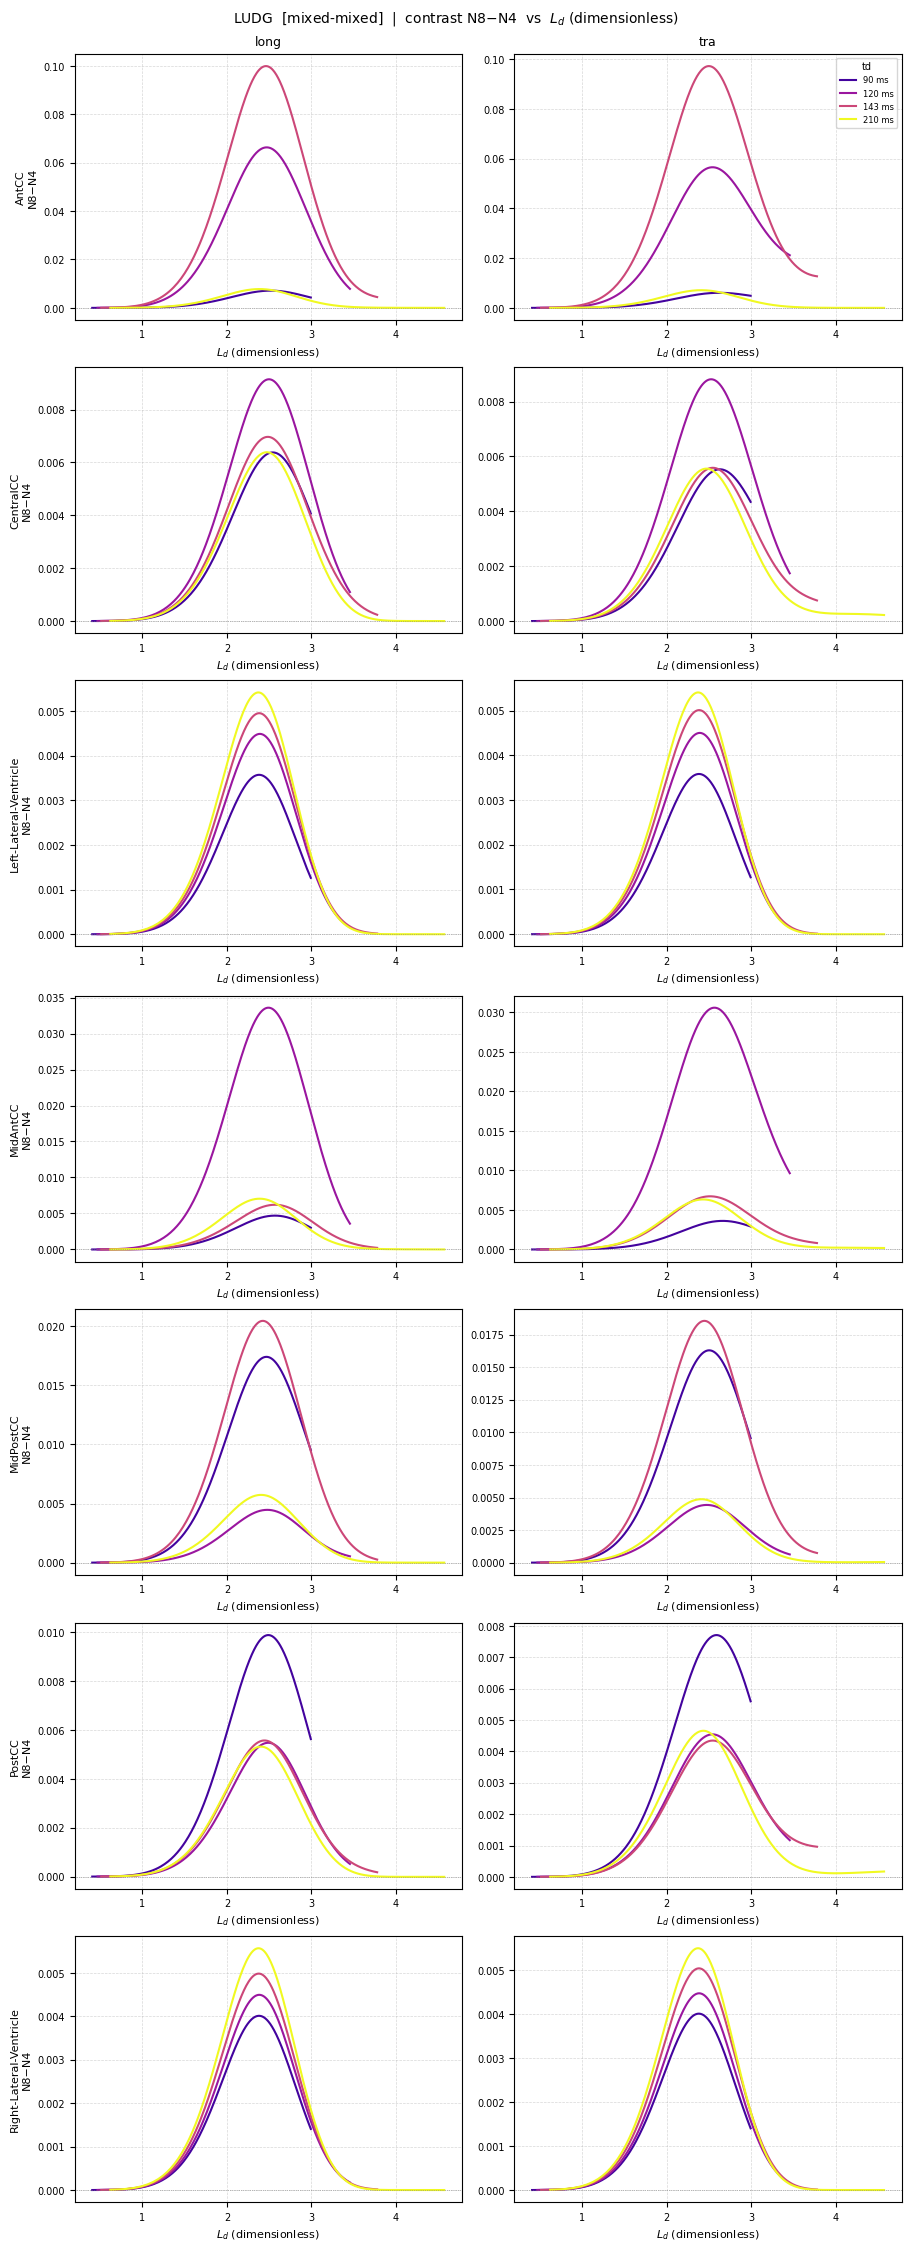

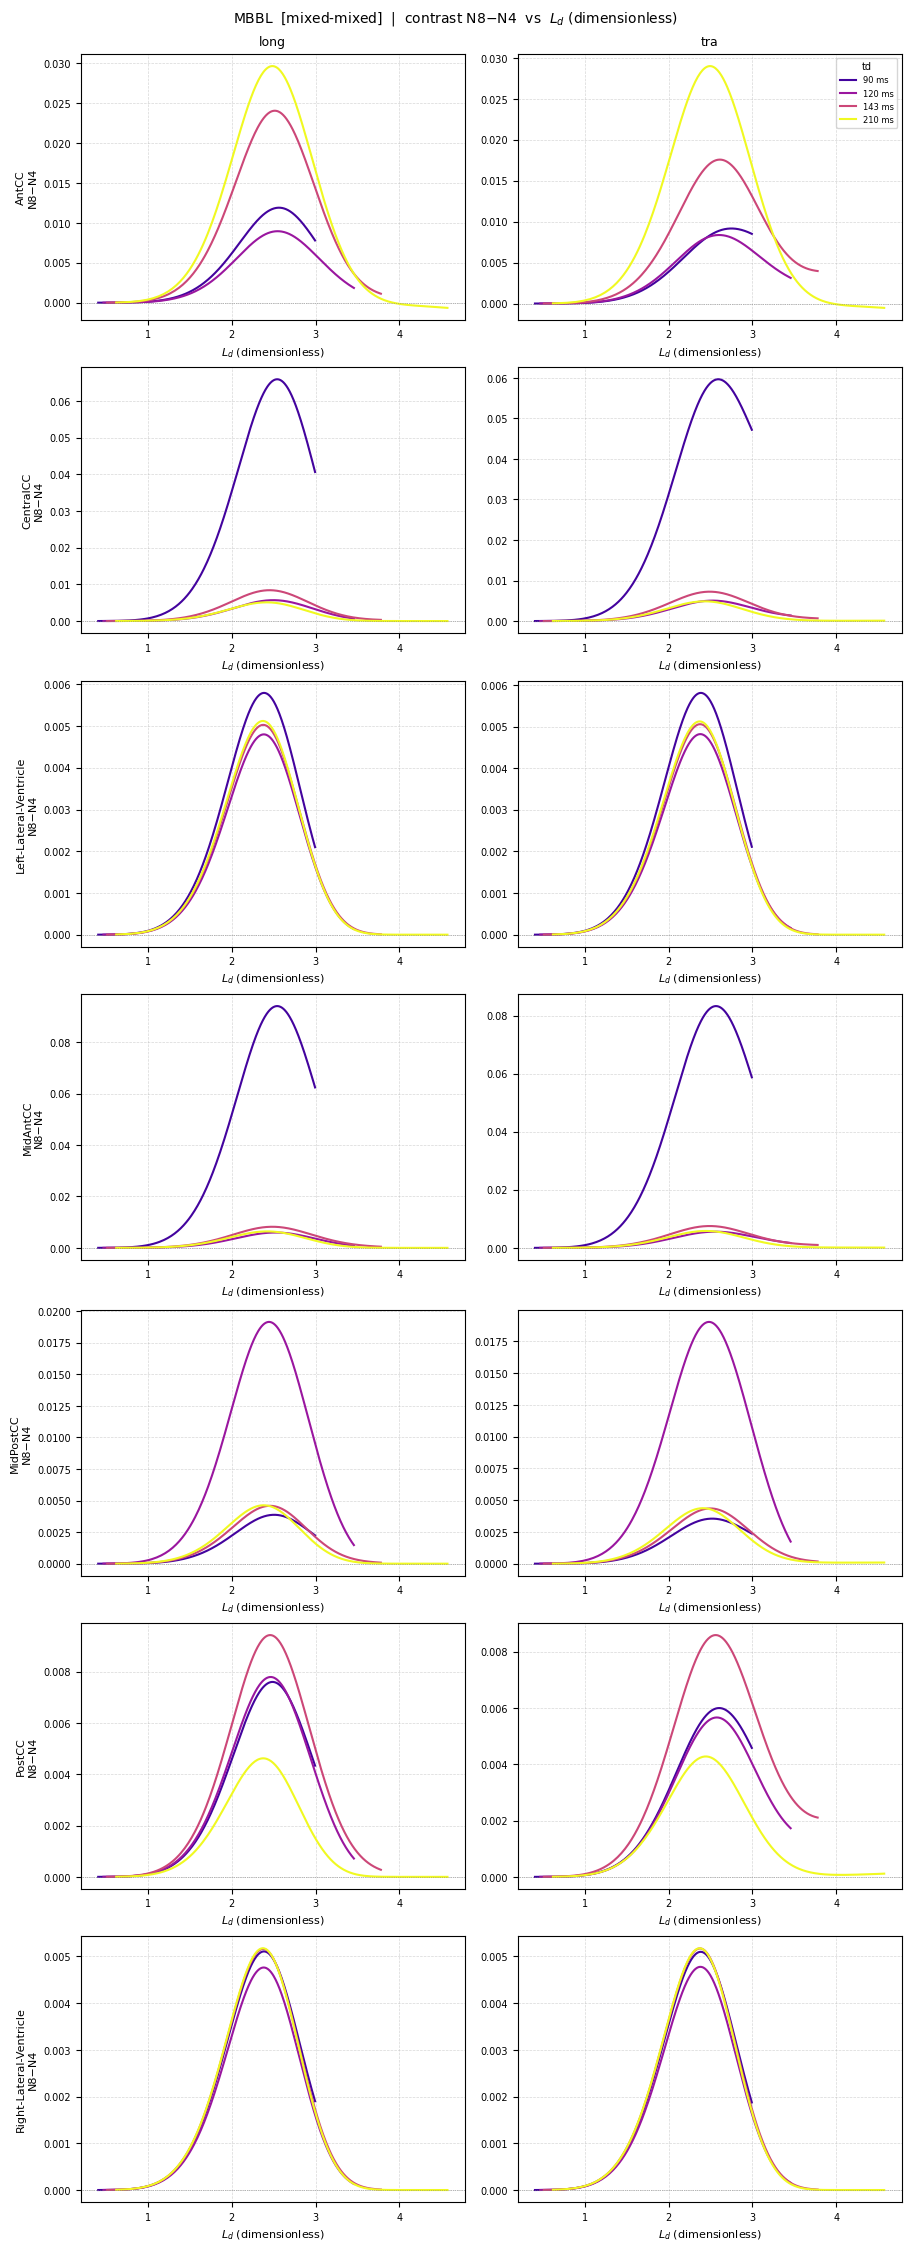

In [77]:
for subj in SUBJ_LIST:
    fig = _summary_contrast_figure(subj, xvar='Ld')
    fig.savefig(OUT_DIR / f"contrast_vs_Ld_{subj}.png", dpi=120)
    plt.show()


### 6b. Contrast vs $L_{cf}$

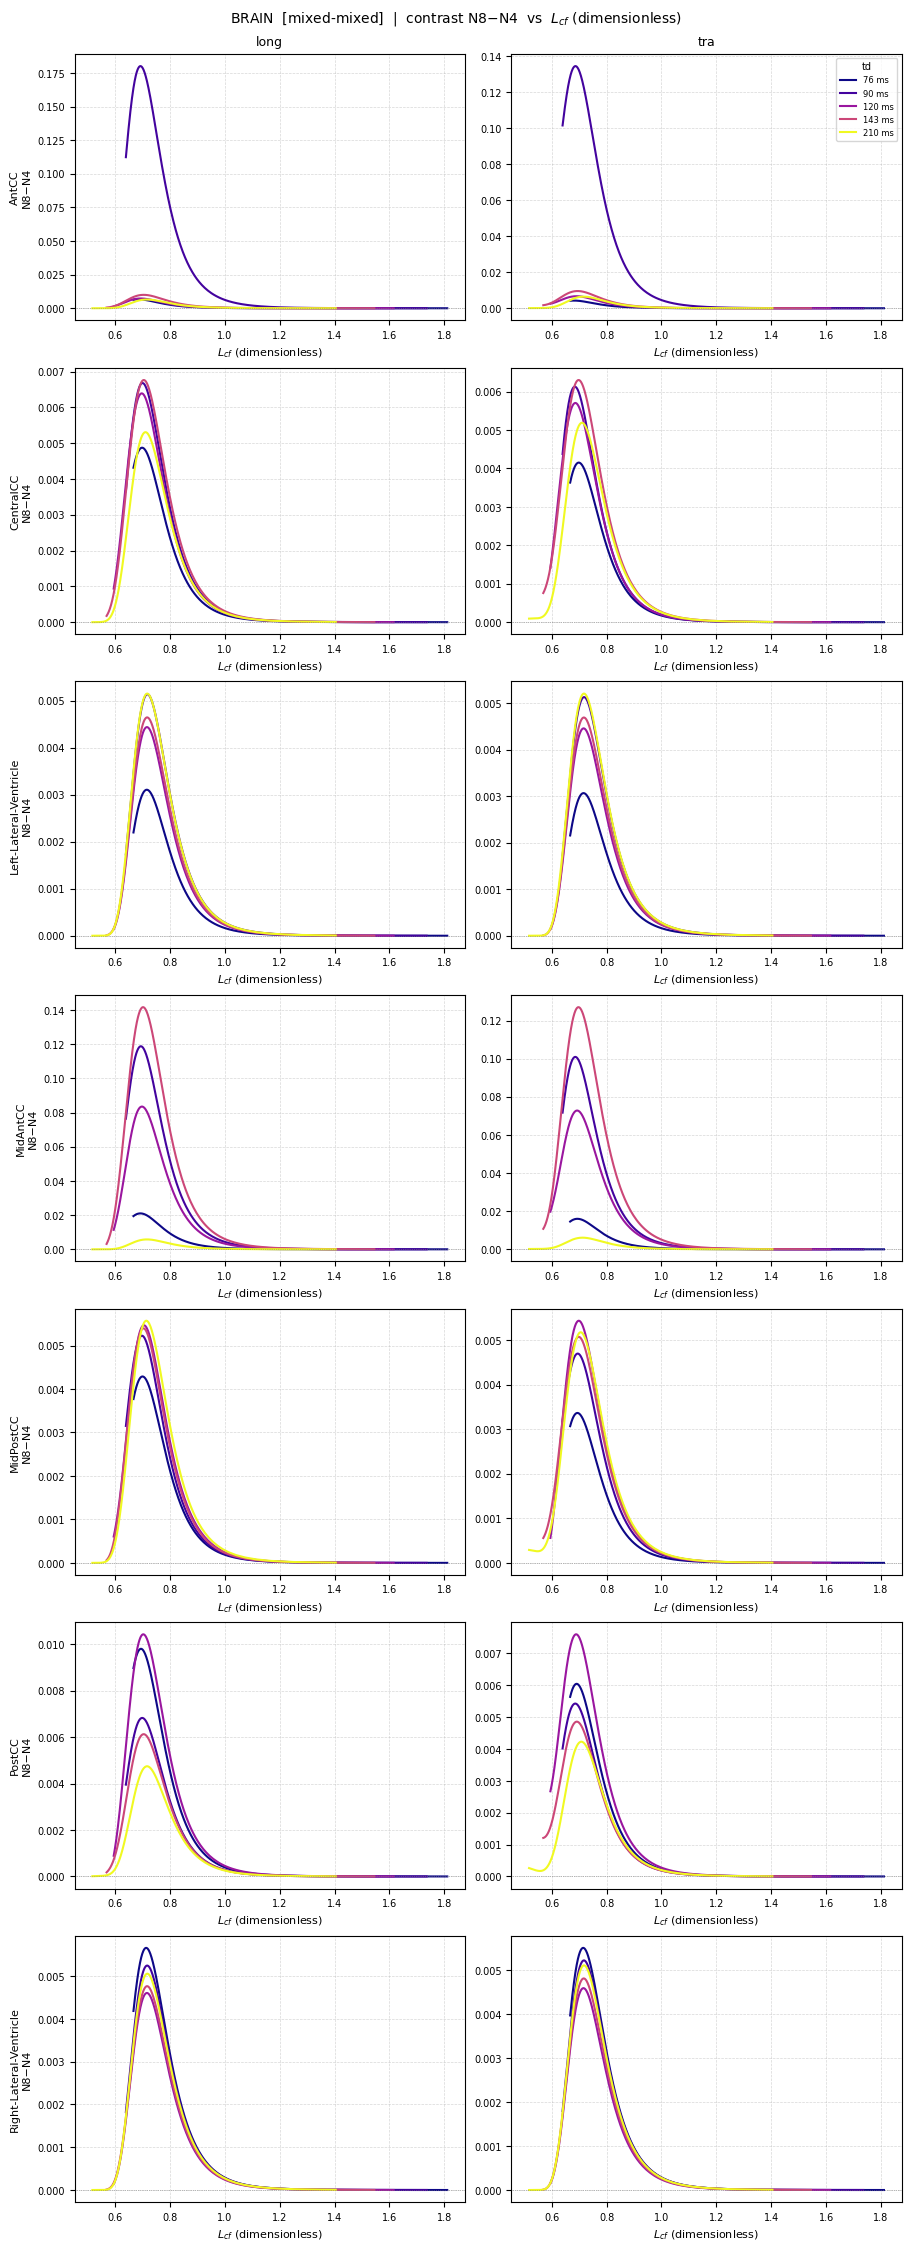

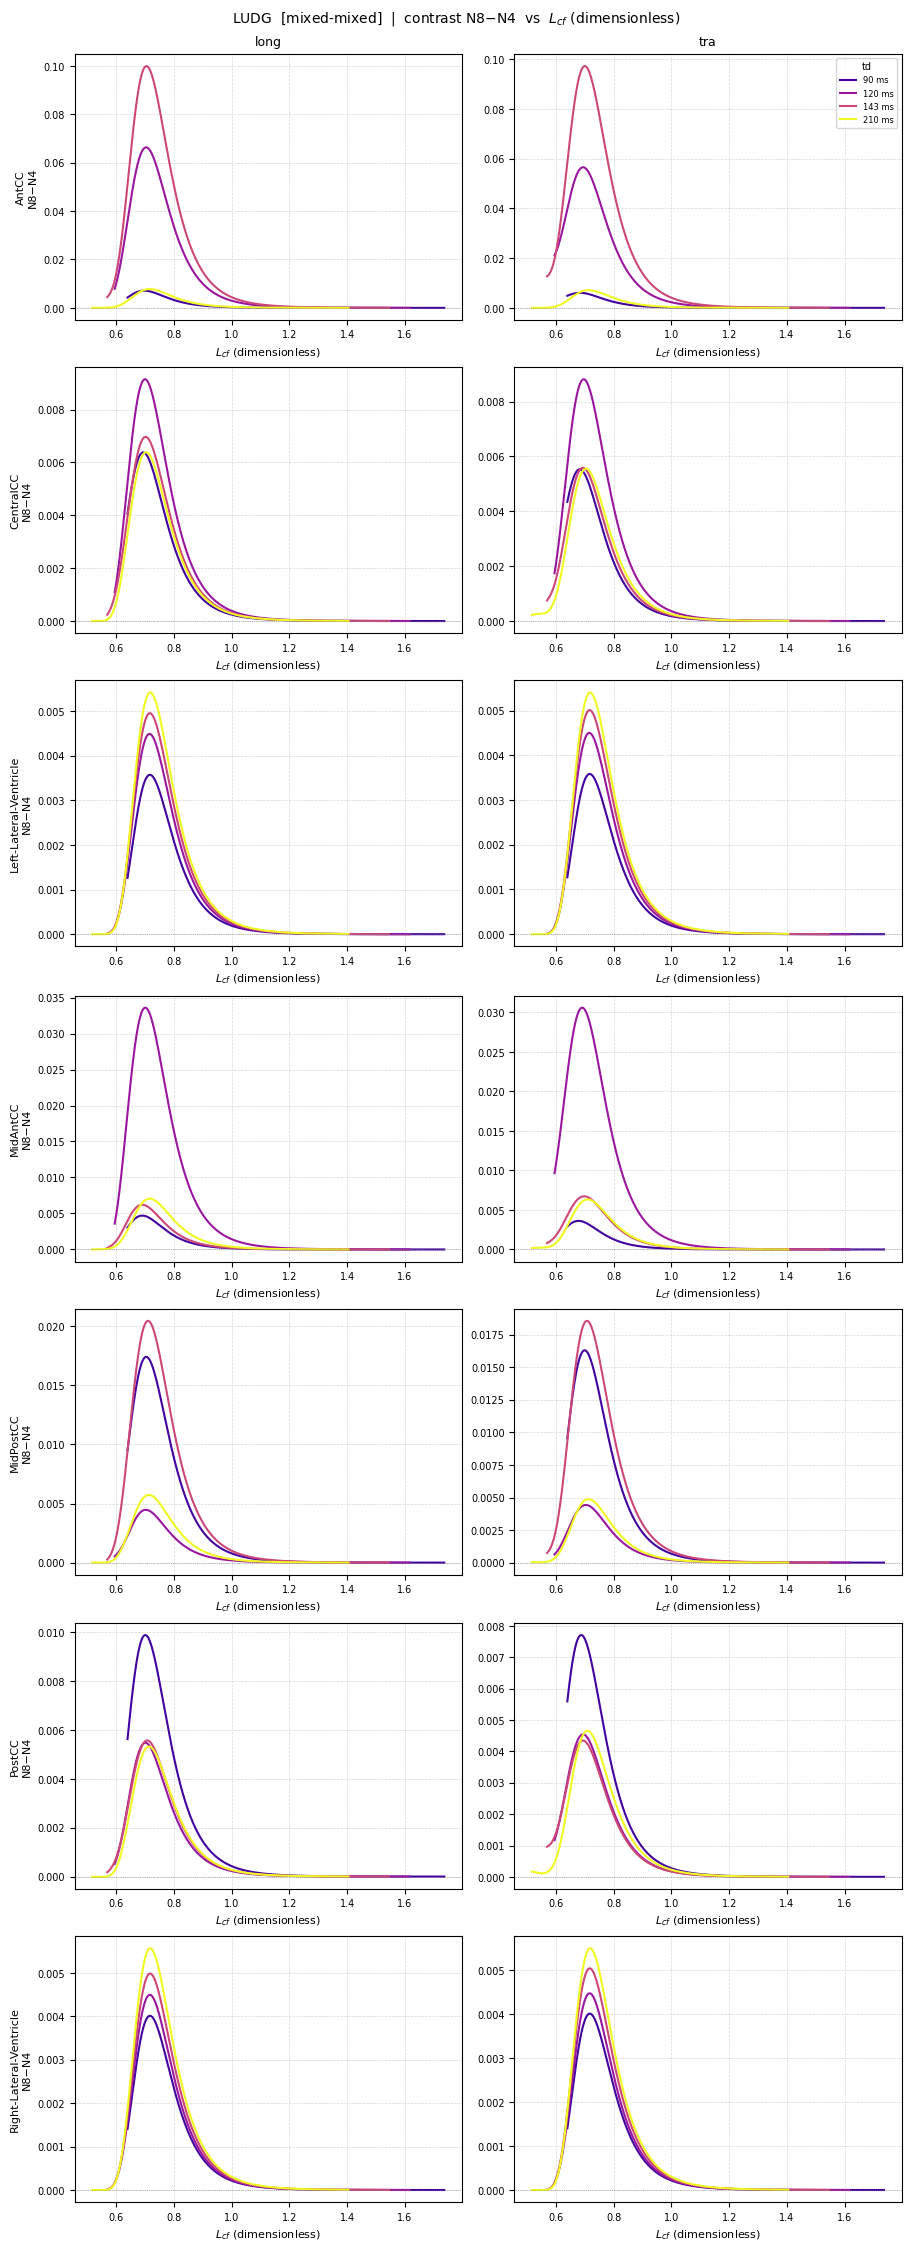

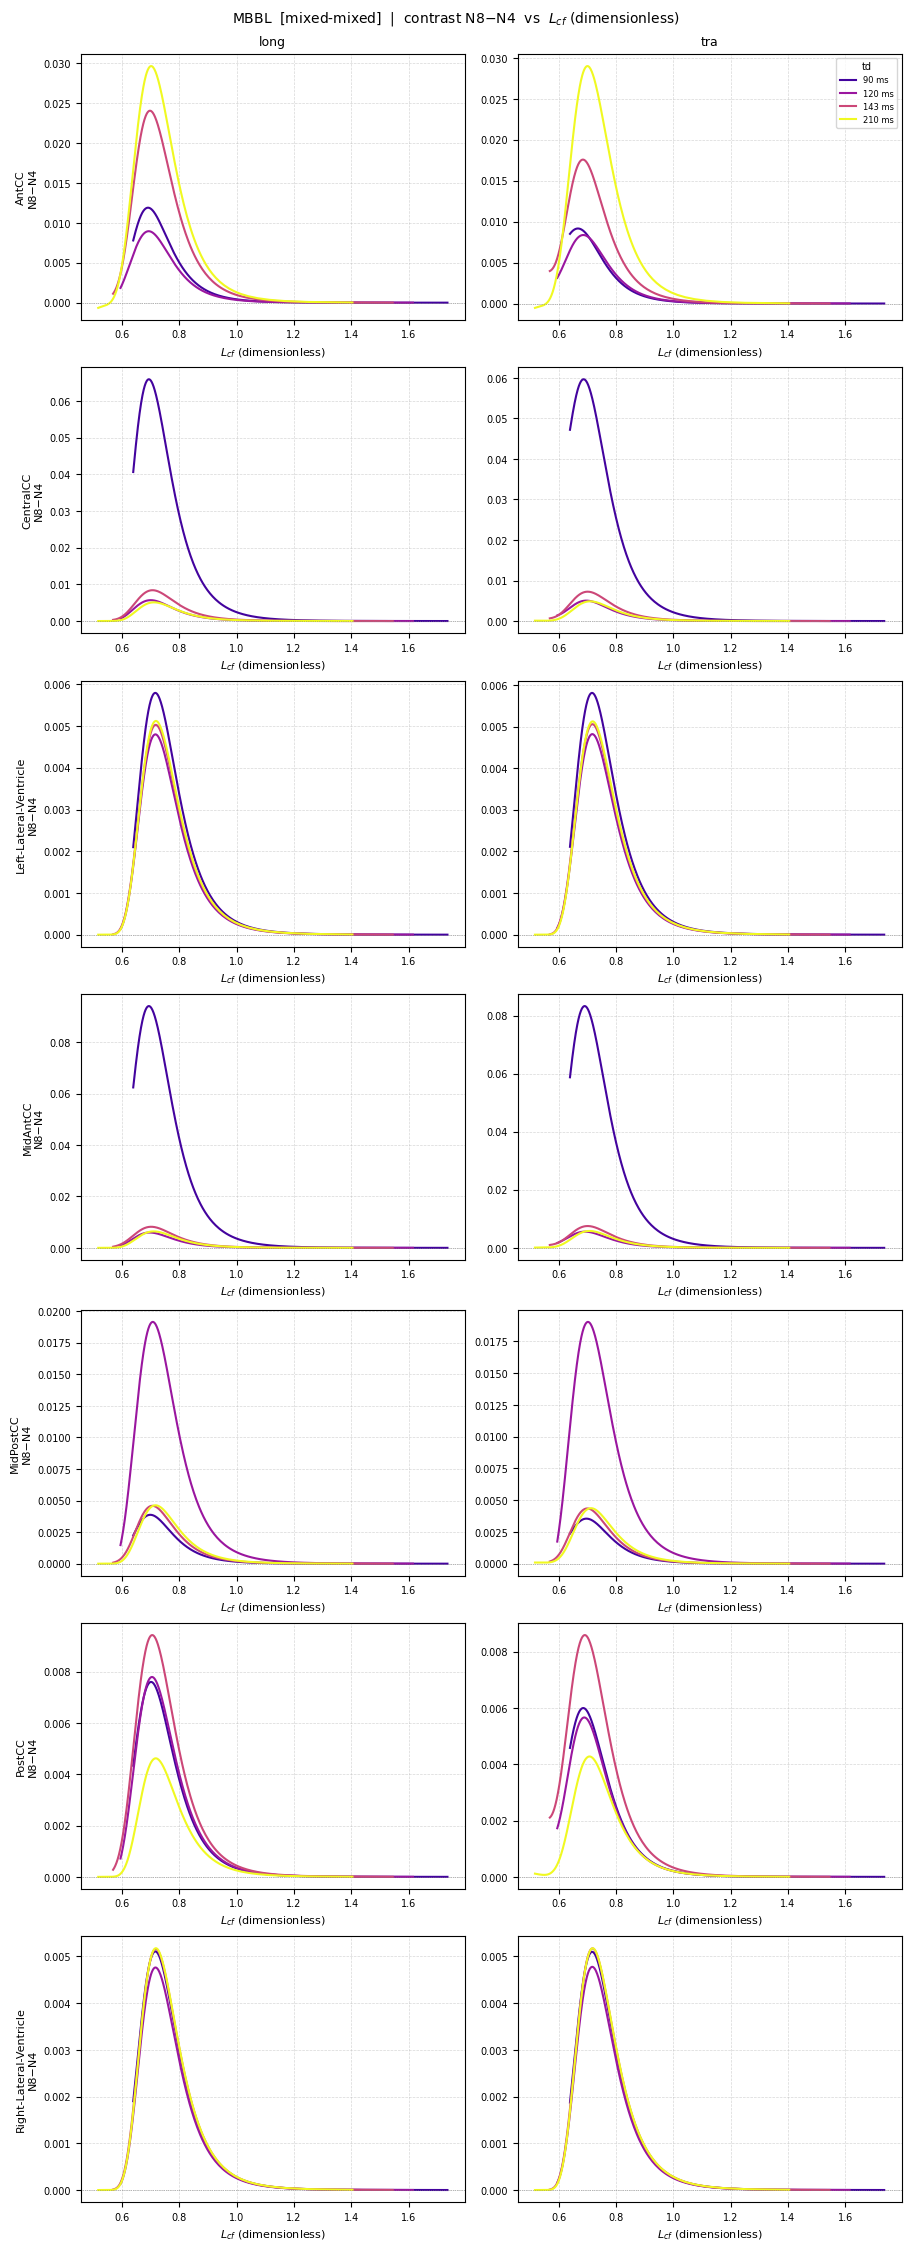

In [78]:
for subj in SUBJ_LIST:
    fig = _summary_contrast_figure(subj, xvar='Lcf')
    fig.savefig(OUT_DIR / f"contrast_vs_Lcf_{subj}.png", dpi=120)
    plt.show()


### 6c. Contrast vs $l_{cf}$ [µm]

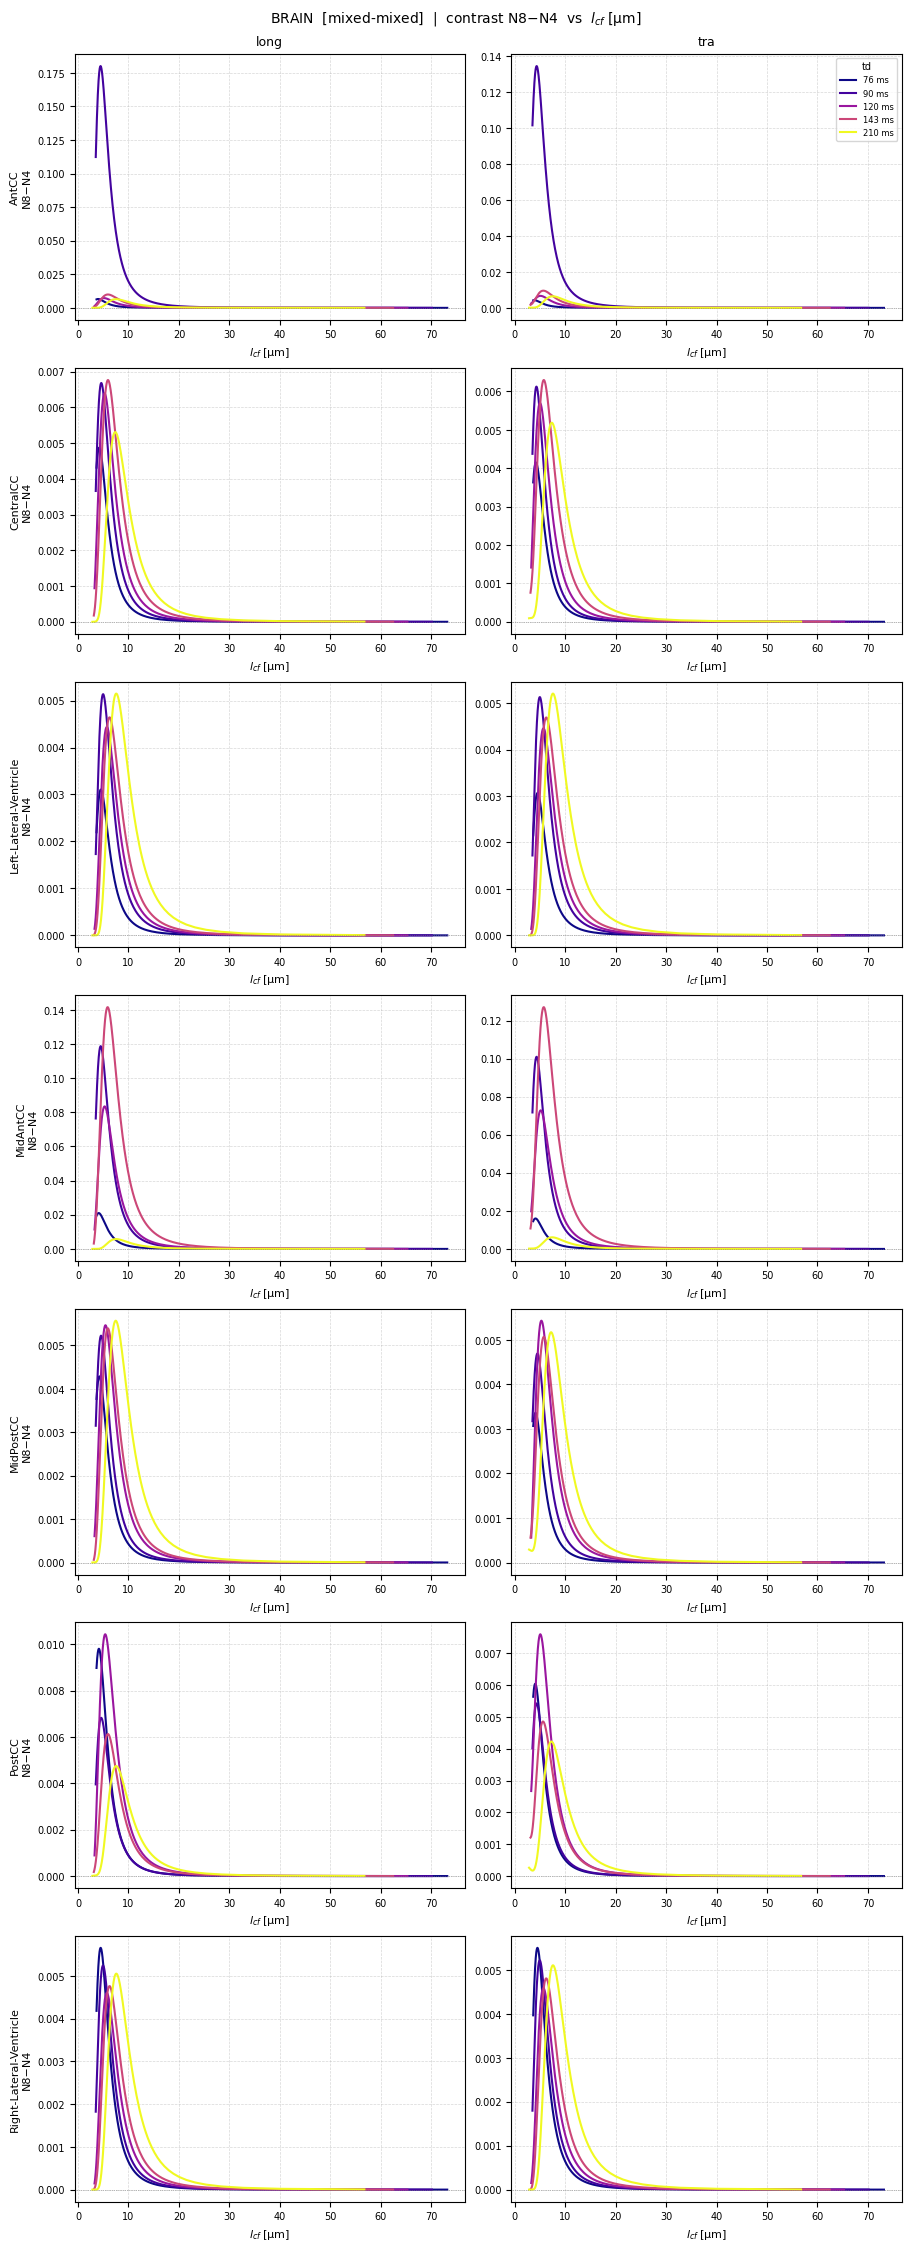

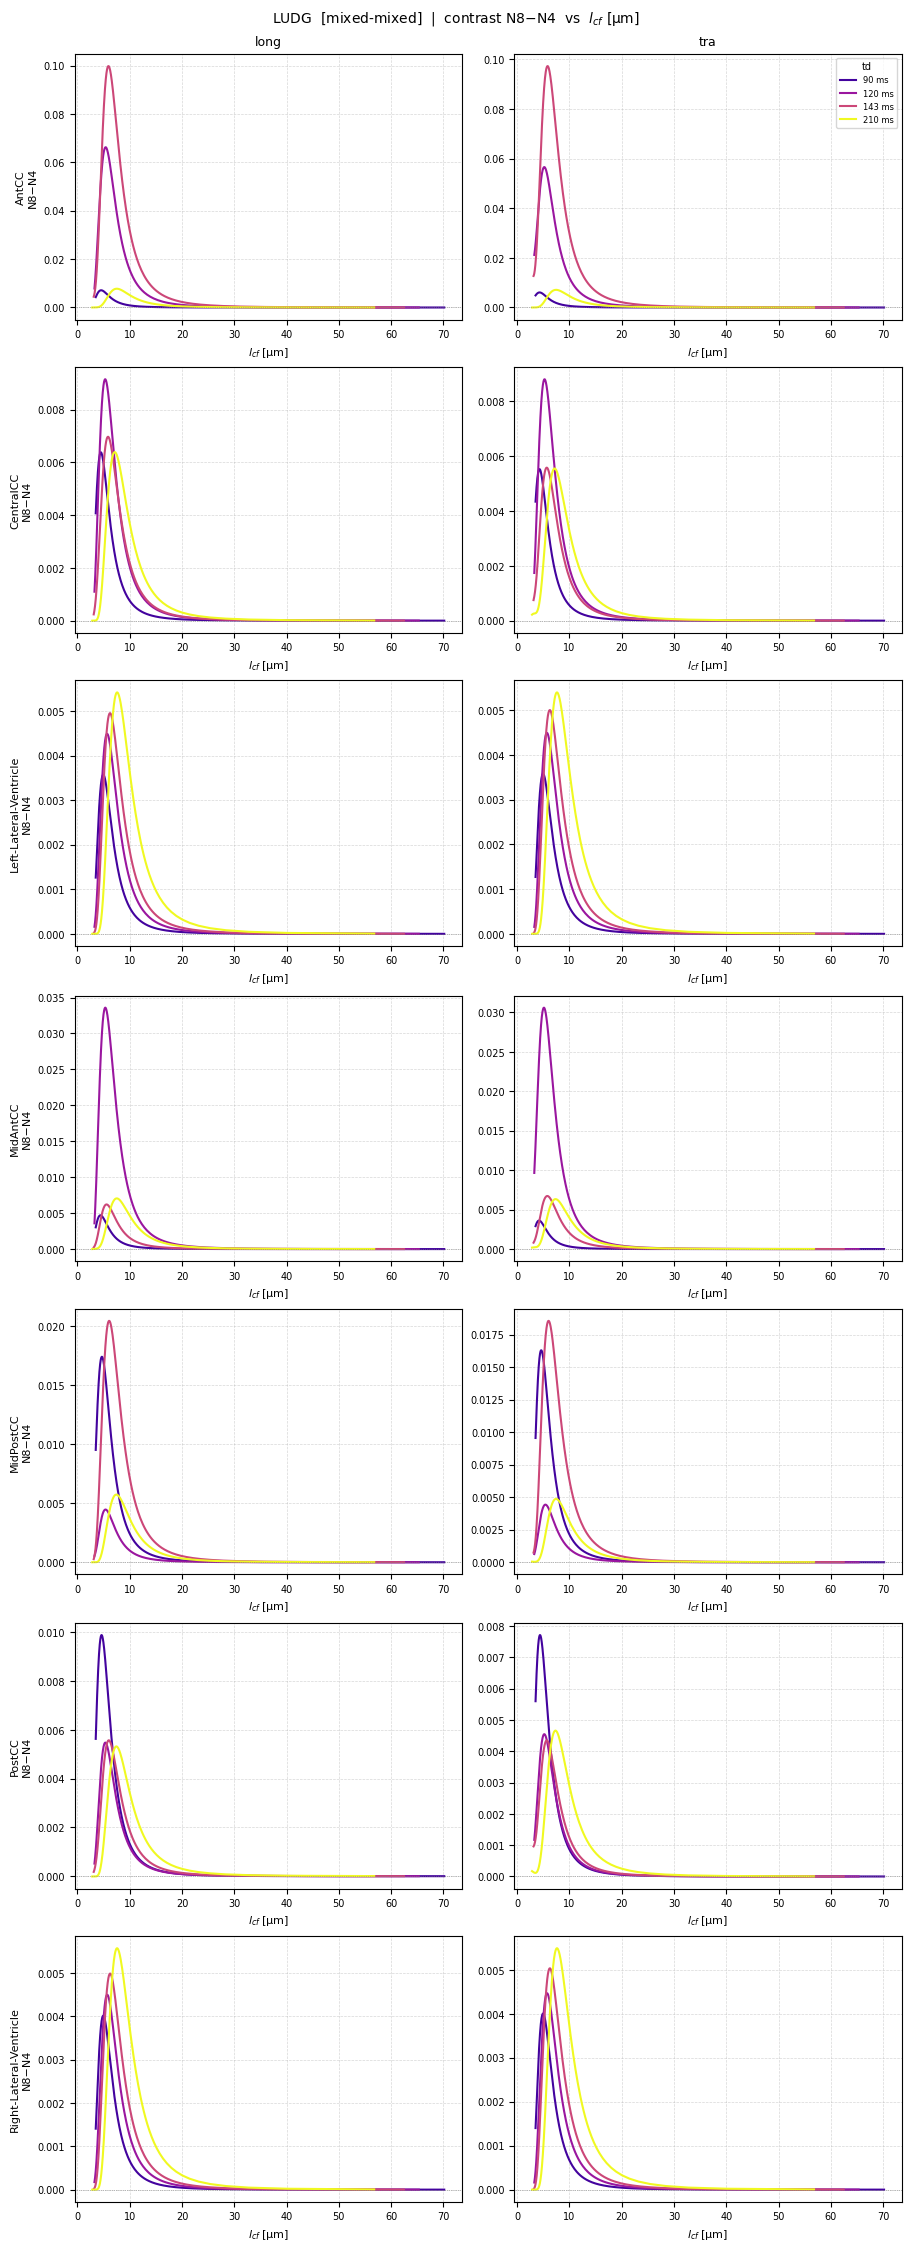

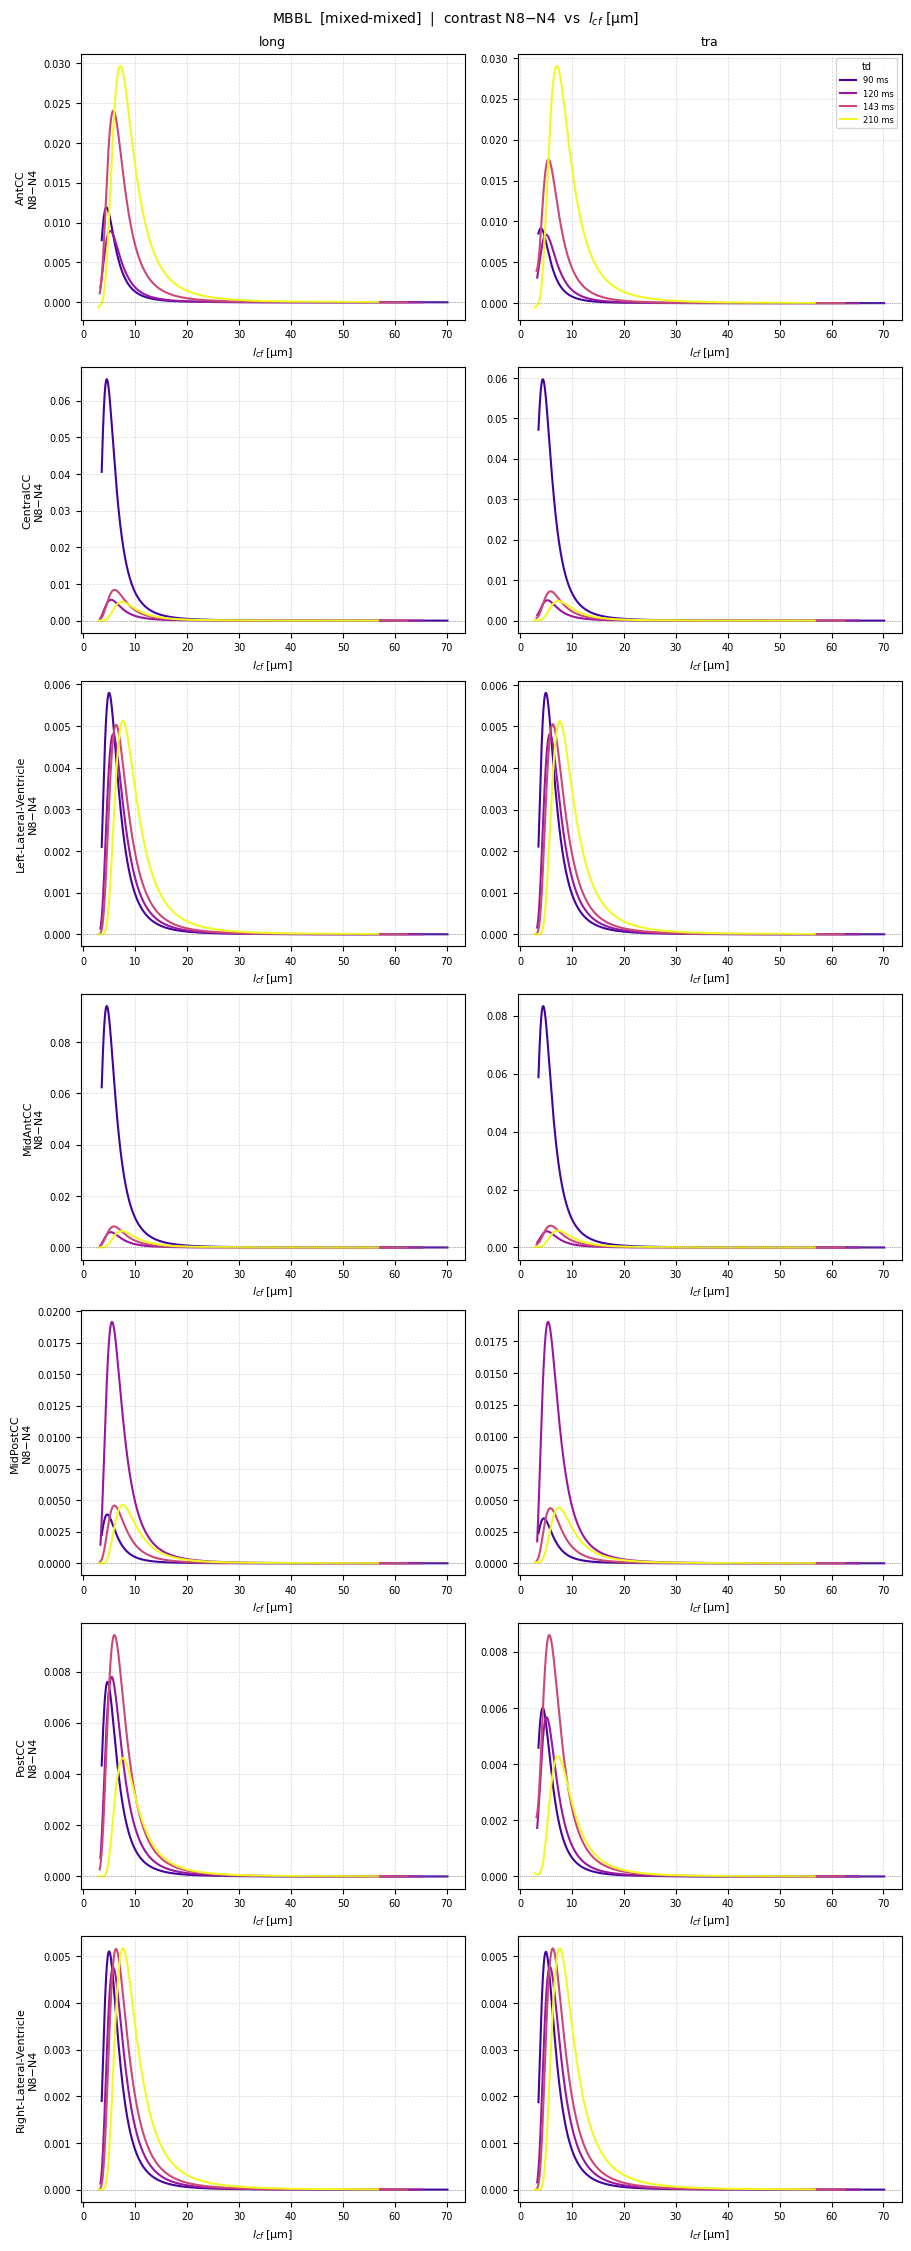

In [79]:
for subj in SUBJ_LIST:
    fig = _summary_contrast_figure(subj, xvar='lcf')
    fig.savefig(OUT_DIR / f"contrast_vs_lcf_{subj}.png", dpi=120)
    plt.show()


## 7. Peak contrast: tc vs td_OGSE

For each `(subj, roi, dir, td)`, finds the G that maximises |contrast|, converts
that G to `lcf [µm]`, then to `tc [ms]` via `tc = (lcf × 10⁻⁶)² / D₀`.

Each subplot (row = ROI, col = direction) shows **tc [ms]** on the x-axis and
**td_OGSE [ms]** on the y-axis, with one marker series per subject.


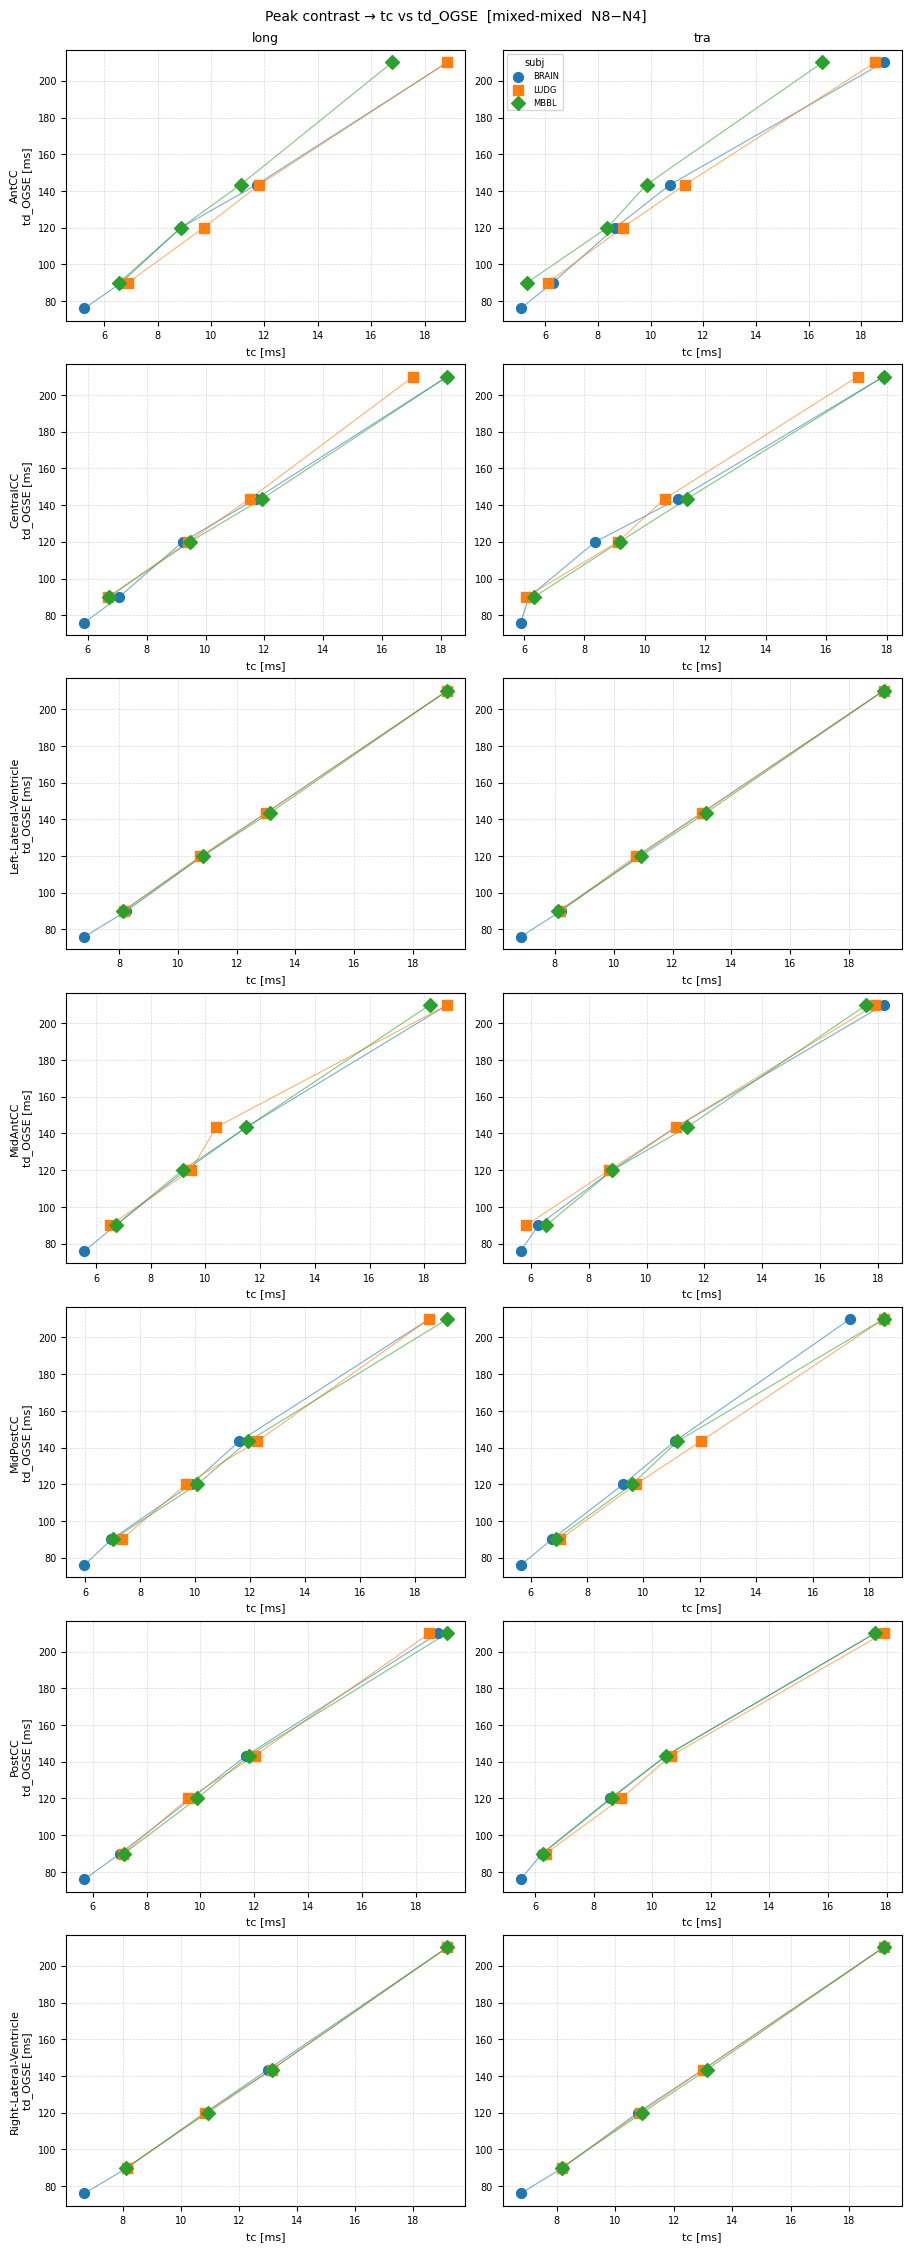

In [80]:
# ── Colour map for subjects ────────────────────────────────────────────────────
_subj_cmap   = plt.get_cmap("tab10")
_subj_colors = {s: _subj_cmap(i % 10) for i, s in enumerate(SUBJ_LIST)}
_subj_markers = ["o", "s", "D", "^", "v", "P", "*"]

fig, axes = plt.subplots(
    len(ROI_LIST), len(DIRECTIONS),
    figsize=(4.5 * len(DIRECTIONS), 3.2 * len(ROI_LIST)),
    squeeze=False,
    constrained_layout=True,
)

for i_roi, roi in enumerate(ROI_LIST):
    for i_dir, direction in enumerate(DIRECTIONS):
        ax = axes[i_roi, i_dir]

        for i_s, subj in enumerate(SUBJ_LIST):
            tc_vals, td_vals = [], []
            for td in TD_LIST:
                tc_pk, _ = _get_peak_tc(td, subj, roi, direction)
                if np.isfinite(tc_pk):
                    tc_vals.append(tc_pk)
                    td_vals.append(td)
            if not tc_vals:
                continue
            ax.scatter(tc_vals, td_vals,
                       color=_subj_colors[subj],
                       marker=_subj_markers[i_s % len(_subj_markers)],
                       s=50, zorder=4, label=subj)
            ax.plot(tc_vals, td_vals,
                    color=_subj_colors[subj], lw=0.8, alpha=0.6)

        ax.set_xlabel("tc [ms]", fontsize=8)
        ax.grid(True, which="major", ls="--", lw=0.5, alpha=0.5)
        ax.set_axisbelow(True)
        ax.tick_params(labelsize=7)

        if i_dir == 0:
            ax.set_ylabel(f"{roi}\ntd_OGSE [ms]", fontsize=8)
        if i_roi == 0:
            ax.set_title(direction, fontsize=9)
        if i_roi == 0 and i_dir == len(DIRECTIONS) - 1:
            ax.legend(fontsize=6, title="subj", title_fontsize=7, loc="best")

rn_tag = "_RN0" if RN_ZERO else ""
fig.suptitle(
    f"Peak contrast → tc vs td_OGSE  [{MODEL_NAME}  N{N_HIGH}−N{N_LOW}{rn_tag}]",
    fontsize=10,
)
fig.savefig(OUT_DIR / f"tc_peak_vs_td{rn_tag}.png", dpi=120)
plt.show()
